
# Does Premium Support Actually Reduce Customer Churn?
### A hands-on project applying *Graphical Causal Models* (Chapter 3, Facure — *Causal Inference in Python*)

**The business question:** Your company sells a SaaS product. Some customers pay extra for a
**Premium Support** tier (faster response times, dedicated agent). The retention team wants to know:

> *Does buying Premium Support actually cause customers to stay (reduce churn), or do we just see
> a correlation because the kind of customer who buys Premium Support was already more likely to
> stay anyway?*

This is a **textbook confounding problem**, and — as a twist — the way we *measure* retention
(via an end-of-quarter satisfaction survey) also introduces a **selection bias** problem, almost
identical in structure to the NPS survey example in the chapter.

We'll use exactly the toolkit from Chapter 3:

1. Encode our beliefs about the world as a **DAG** (`networkx` / `graphviz`).
2. Use **d-separation** to reason about which variables open/close paths of association.
3. Distinguish the **causal path** from the **backdoor (confounding) path**.
4. Apply the **adjustment formula** / conditional independence assumption (CIA) to estimate
   the true causal effect from observational data.
5. Show how **conditioning on a collider** (the survey-response variable) reintroduces bias,
   even after we've fixed the confounding — and how to (partially) correct for it.

> This notebook is self-contained: we simulate data with a **known ground-truth causal effect**,
> so at the end we can check whether our causal-inference toolkit recovered the truth.


## Step 0 — Setup

In [1]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import graphviz as gr

np.random.seed(42)
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110



## Step 1 — Write down our causal story (before touching any data)

Just like the book's "Are Consultants Worth It?" example, before we look at data we should be
explicit about **why we think Premium Support and retention are related**.

Our beliefs:

- **Account tenure / past engagement (`U`, unobserved... but partly measurable via `past_usage`)**
  drives *both*:
  - the decision to buy Premium Support (happier, more invested customers upgrade), **and**
  - future retention (engaged customers churn less anyway).
- Premium Support may have a **real, direct causal effect** on retention (`T → Y`).
- Retention itself is measured through a **quarterly satisfaction survey**. Not everyone responds.
  Both Premium Support *and* the customer's actual happiness affect the odds of responding
  (`T → Response`, `Y → Response`). This is a **collider** structure — exactly like the NPS
  example in the chapter.

Let's draw the DAG.


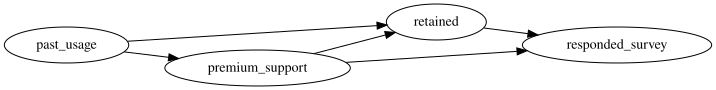

In [2]:

g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.attr('node', shape='ellipse')

g.edge("past_usage", "premium_support")
g.edge("past_usage", "retained")
g.edge("premium_support", "retained")          # the causal effect we care about
g.edge("premium_support", "responded_survey")
g.edge("retained", "responded_survey")         # collider!

g



**Reading the graph:**

- `past_usage → premium_support` and `past_usage → retained`: a **fork** (confounder).
  `past_usage` is a common cause, so `premium_support` and `retained` will look associated
  even if Premium Support does nothing.
- `premium_support → retained`: the **causal path** we actually want to measure.
- `premium_support → responded_survey ← retained`: an **immorality / collider**. If we
  (accidentally) condition on `responded_survey` — e.g. by only analyzing customers who
  answered the survey — we open a *noncausal* path between `premium_support` and `retained`.



## Step 2 — Simulate data with a *known* ground-truth effect

Because we're learning the method, we'll simulate data where **we control the true causal
effect** of Premium Support on retention. That way, at the end, we can check whether our
causal-inference pipeline recovers the number we put in.

**Ground truth we're baking in:** Premium Support increases the probability of retention by
**+12 percentage points** (`TRUE_ATE = 0.12`), on top of whatever `past_usage` already
contributes.


In [3]:

n = 20_000
TRUE_ATE = 0.12  # the ground-truth causal effect we're hiding in the simulation

# past_usage: standardized measure of how engaged the customer was BEFORE this quarter
# (0 = low engagement, 1 = high engagement)
past_usage = np.random.beta(2, 2, n)

# Premium Support purchase is NOT random: more engaged customers are more likely to buy it
# (this is the confounding mechanism)
p_premium = 1 / (1 + np.exp(-(4 * past_usage - 2)))
premium_support = np.random.binomial(1, p_premium)

# True retention probability:
#   baseline driven by past_usage (confounder)
# + TRUE_ATE if they bought premium support (the causal effect)
# + noise
p_retained = np.clip(0.15 + 0.55 * past_usage + TRUE_ATE * premium_support, 0.01, 0.99)
retained = np.random.binomial(1, p_retained)

# Survey response: both premium_support customers AND retained (happy) customers
# are more likely to respond to the quarterly survey -> collider
p_response = 1 / (1 + np.exp(-(-1.5 + 2.2 * premium_support + 2.0 * retained)))
responded_survey = np.random.binomial(1, p_response)

df = pd.DataFrame({
    "past_usage": past_usage,
    "premium_support": premium_support,
    "retained": retained,
    "responded_survey": responded_survey,
})

df.head()


,past_usage,premium_support,retained,responded_survey
0,0.616,0,1,1
1,0.500,1,1,1
2,0.619,1,1,1
3,0.314,0,0,1
4,0.903,1,1,1



## Step 3 — The naive (wrong) comparison

The retention team's first instinct: just compare retention rates between Premium Support
customers and everyone else.


In [4]:

naive_effect = (
    df.query("premium_support == 1")["retained"].mean()
    - df.query("premium_support == 0")["retained"].mean()
)
print(f"Naive difference in retention rate: {naive_effect:.3f}")
print(f"True causal effect (ground truth):   {TRUE_ATE:.3f}")
print(f"Bias in the naive estimate:          {naive_effect - TRUE_ATE:.3f}")


Naive difference in retention rate: 0.223
True causal effect (ground truth):   0.120
Bias in the naive estimate:          0.103



The naive number is way too high. Just like the "Are Consultants Worth It?" example in the
book, this is **confounding bias**: customers who buy Premium Support were already more likely
to stick around, *regardless* of the support tier.



## Step 4 — Verify the confounding structure with d-separation

Let's encode the DAG in `networkx` (the library the book uses for `d_separated`) and formally
check what we already suspect: `premium_support` and `retained` are **not independent**, and
that dependence flows through `past_usage`.


In [5]:

model = nx.DiGraph([
    ("past_usage", "premium_support"),
    ("past_usage", "retained"),
    ("premium_support", "retained"),
    ("premium_support", "responded_survey"),
    ("retained", "responded_survey"),
])

def dependent(g, x, y, z=set()):
    return not nx.is_d_separator(g, {x}, {y}, set(z))

print("Are premium_support and retained dependent (no conditioning)?     ",
      dependent(model, "premium_support", "retained"))
print("Are premium_support and retained dependent, given past_usage?     ",
      dependent(model, "premium_support", "retained", {"past_usage"}))


Are premium_support and retained dependent (no conditioning)?      True
Are premium_support and retained dependent, given past_usage?      True



> **Note:** depending on your installed `networkx` version, the function is called either
> `nx.d_separated` (older) or `nx.is_d_separator` (newer). Run the cell below if the one above
> raised an `AttributeError`.


In [6]:

# Fallback for older networkx versions
try:
    nx.is_d_separator
except AttributeError:
    def dependent(g, x, y, z=set()):
        return not nx.d_separated(g, {x}, {y}, set(z))
    print("Are premium_support and retained dependent (no conditioning)?     ",
          dependent(model, "premium_support", "retained"))
    print("Are premium_support and retained dependent, given past_usage?     ",
          dependent(model, "premium_support", "retained", {"past_usage"}))



This confirms the theory:

- **Without conditioning:** `premium_support` and `retained` are dependent — as expected,
  since there's both a causal path *and* a backdoor path through `past_usage`.
- **Conditioning on `past_usage`:** they're *still* dependent — good! That's expected too,
  because the **direct causal edge** `premium_support → retained` is still open. If they were
  independent after conditioning, it would mean Premium Support has *no* effect at all.

What conditioning on `past_usage` does is **close the backdoor path**, isolating the causal
association. Let's prove that explicitly by deleting the causal edge and re-checking — this is
the same "severed graph" trick from the book.


In [7]:

severed = nx.DiGraph([
    ("past_usage", "premium_support"),
    ("past_usage", "retained"),
    ("premium_support", "responded_survey"),
    ("retained", "responded_survey"),
    # ("premium_support", "retained"),  <-- causal edge removed
])

still_dependent_no_adjustment = dependent(severed, "premium_support", "retained")
still_dependent_with_adjustment = dependent(severed, "premium_support", "retained", {"past_usage"})

print("With the causal edge removed:")
print("  Still dependent (no adjustment)?  ", still_dependent_no_adjustment, " <- this is the backdoor path (bias)")
print("  Still dependent, given past_usage?", still_dependent_with_adjustment, " <- adjusting closes it")


With the causal edge removed:
  Still dependent (no adjustment)?   True  <- this is the backdoor path (bias)
  Still dependent, given past_usage? False  <- adjusting closes it



## Step 5 — Backdoor adjustment: estimate the true ATE

Since `past_usage` is continuous, we can't literally "group by" it like the book's discrete
consultancy example. In practice this is done via **stratification into bins** or, more commonly
in industry, **linear/logistic regression adjustment** — both are implementations of the same
adjustment formula:

$$ATE = \sum_x \big(E[Y \mid T=1, X=x] - E[Y \mid T=0, X=x]\big) P(X=x)$$

### 5a — Stratification (bins), matching the book's approach directly


In [8]:

df["usage_bin"] = pd.qcut(df["past_usage"], q=10)

strata = (
    df.groupby(["usage_bin", "premium_support"])["retained"]
    .mean()
    .unstack()
)
strata["effect"] = strata[1] - strata[0]
strata_sizes = df.groupby("usage_bin").size()

# weighted average of in-group effects, weighted by group size (the adjustment formula)
adjusted_ate_strata = (strata["effect"] * strata_sizes / strata_sizes.sum()).sum()

print(strata[["effect"]])
print(f"\nBackdoor-adjusted ATE (stratification): {adjusted_ate_strata:.3f}")
print(f"True causal effect (ground truth):       {TRUE_ATE:.3f}")


premium_support   effect
usage_bin               
(0.00051, 0.194]   0.149
(0.194, 0.286]     0.104
(0.286, 0.364]     0.135
(0.364, 0.434]     0.118
(0.434, 0.501]     0.122
(0.501, 0.568]     0.118
(0.568, 0.638]     0.137
(0.638, 0.709]     0.154
(0.709, 0.801]     0.134
(0.801, 0.994]     0.126

Backdoor-adjusted ATE (stratification): 0.130
True causal effect (ground truth):       0.120


### 5b — Regression adjustment (equivalent, more common in practice)

In [9]:

import statsmodels.formula.api as smf

model_adj = smf.ols("retained ~ premium_support + past_usage", data=df).fit()
print(model_adj.summary().tables[1])

adjusted_ate_regression = model_adj.params["premium_support"]
print(f"\nBackdoor-adjusted ATE (regression):     {adjusted_ate_regression:.3f}")
print(f"True causal effect (ground truth):       {TRUE_ATE:.3f}")


                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1533      0.008     18.589      0.000       0.137       0.169
premium_support     0.1274      0.007     17.385      0.000       0.113       0.142
past_usage          0.5361      0.016     32.625      0.000       0.504       0.568

Backdoor-adjusted ATE (regression):     0.127
True causal effect (ground truth):       0.120



Both approaches land very close to the true `0.12` effect we simulated — because conditioning
on `past_usage` (the confounder) satisfies the **conditional independence assumption (CIA)**:
$(Y_0, Y_1) \perp T \mid X$. Within each engagement level, Premium Support is "as good as
randomly assigned."

This only works because we assumed `past_usage` is the *only* common cause. In real life, you'd
want to sanity-check that assumption (e.g. sensitivity analysis, as the book flags in the sidebar
on Cinelli & Hazlett's omitted-variable-bias framework).



## Step 6 — The trap: conditioning on the collider (selection bias)

Now suppose the retention team only trusts the **survey data**, since that's where "true
satisfaction" is recorded, and restricts the whole analysis to `responded_survey == 1`. This
feels harmless — but `responded_survey` is a **collider** (`premium_support → responded_survey ←
retained`). Conditioning on it — even implicitly, by only working with survey respondents — opens
a *new*, purely noncausal path between `premium_support` and `retained`.


In [10]:

print("Are premium_support / retained dependent given past_usage AND responded_survey?")
print(" ", dependent(model, "premium_support", "retained", {"past_usage", "responded_survey"}))
print("(this should now be True even in the SEVERED graph -> that dependence is pure bias)")

severed_check = dependent(severed, "premium_support", "retained", {"past_usage", "responded_survey"})
print("\nSevered graph (no causal edge), conditioning on past_usage AND responded_survey:")
print(" ", severed_check, " <- if True, this confirms a bias-only path has been opened")


Are premium_support / retained dependent given past_usage AND responded_survey?
  True
(this should now be True even in the SEVERED graph -> that dependence is pure bias)

Severed graph (no causal edge), conditioning on past_usage AND responded_survey:
  True  <- if True, this confirms a bias-only path has been opened


In [11]:

# Now repeat the regression, but restricted to survey respondents only
respondents = df.query("responded_survey == 1")
print(f"Response rate among Premium Support customers: {df.query('premium_support==1')['responded_survey'].mean():.2%}")
print(f"Response rate among standard customers:         {df.query('premium_support==0')['responded_survey'].mean():.2%}")

biased_model = smf.ols("retained ~ premium_support + past_usage", data=respondents).fit()
biased_ate = biased_model.params["premium_support"]

print(f"\n'Survey-only' adjusted ATE (selection-biased): {biased_ate:.3f}")
print(f"Full-sample adjusted ATE (Step 5b):              {adjusted_ate_regression:.3f}")
print(f"True causal effect (ground truth):               {TRUE_ATE:.3f}")


Response rate among Premium Support customers: 82.26%
Response rate among standard customers:         34.45%

'Survey-only' adjusted ATE (selection-biased): -0.065
Full-sample adjusted ATE (Step 5b):              0.127
True causal effect (ground truth):               0.120



Notice the estimate moves away from the truth again — even though we *correctly* adjusted for
`past_usage`. This is **selection bias**, and critically: **it does not go away with more data,
and it would persist even if `premium_support` had been randomly assigned (an A/B test)**. This
is exactly the warning the book gives about the NPS survey example — selection bias is sneakier
than confounding because experimentation alone doesn't fix it.



## Step 7 — Mitigating the selection bias

The book's guidance: to adjust for selection bias, you must adjust for whatever *causes*
selection, and assume the outcome doesn't affect selection *directly* (only through observable,
measurable causes). In our simulation `responded_survey` is directly caused by `retained` itself
(unmeasurable happiness), so this specific bias **cannot be fully removed** — only reduced with
good proxies (e.g. "days since last login," "number of support tickets," etc., standing in for
`retained`).

The one fully correct fix here is structural, not statistical: **use retention data for ALL
customers (e.g. from billing/subscription records), not just the subset who filled out a survey.**
This is a case where the right causal-inference move is a **measurement/data-collection fix**,
not a modeling fix — which is a very common real-world resolution to this exact trap.


In [12]:

print("Comparison of all estimates:\n")
print(f"{'Naive (no adjustment)':40s}: {naive_effect:.3f}")
print(f"{'Backdoor-adjusted (stratification)':40s}: {adjusted_ate_strata:.3f}")
print(f"{'Backdoor-adjusted (regression)':40s}: {adjusted_ate_regression:.3f}")
print(f"{'Backdoor-adjusted, survey-only (biased)':40s}: {biased_ate:.3f}")
print(f"{'TRUE ground-truth effect':40s}: {TRUE_ATE:.3f}")


Comparison of all estimates:

Naive (no adjustment)                   : 0.223
Backdoor-adjusted (stratification)      : 0.130
Backdoor-adjusted (regression)          : 0.127
Backdoor-adjusted, survey-only (biased) : -0.065
TRUE ground-truth effect                : 0.120



## Step 8 — Visualize the flow of association (cheat-sheet style)

A small helper to visualize any DAG with conditioned nodes shaded, mirroring Figure 3-1 in the
book.


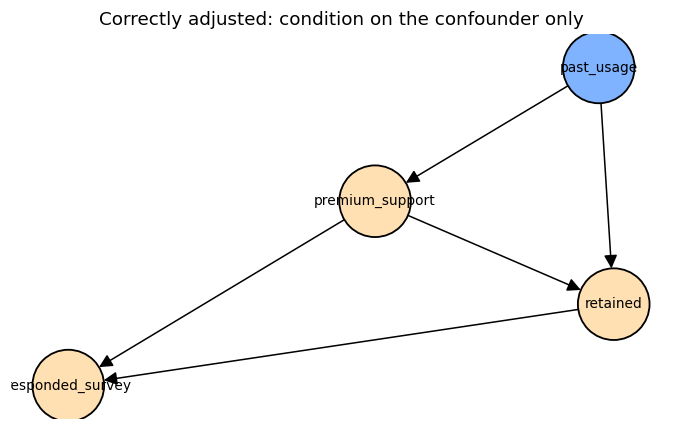

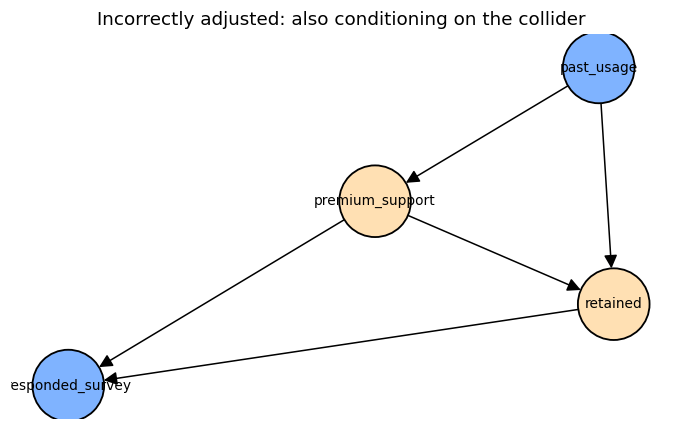

In [13]:

def draw_dag(edges, conditioned=set(), title=""):
    G = nx.DiGraph(edges)
    pos = nx.spring_layout(G, seed=7, k=1.2)
    colors = ["#7fb3ff" if n in conditioned else "#ffe0b3" for n in G.nodes()]
    plt.figure(figsize=(6, 3.5))
    nx.draw(
        G, pos, with_labels=True, node_color=colors, node_size=2200,
        font_size=9, arrowsize=18, edgecolors="black", linewidths=1.2
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

draw_dag(
    edges=[
        ("past_usage", "premium_support"),
        ("past_usage", "retained"),
        ("premium_support", "retained"),
        ("premium_support", "responded_survey"),
        ("retained", "responded_survey"),
    ],
    conditioned={"past_usage"},
    title="Correctly adjusted: condition on the confounder only",
)

draw_dag(
    edges=[
        ("past_usage", "premium_support"),
        ("past_usage", "retained"),
        ("premium_support", "retained"),
        ("premium_support", "responded_survey"),
        ("retained", "responded_survey"),
    ],
    conditioned={"past_usage", "responded_survey"},
    title="Incorrectly adjusted: also conditioning on the collider",
)



## Key takeaways

1. **Always draw the DAG first.** Before touching data, write down what you believe causes what.
   It forces your assumptions into the open, where they can be checked.
2. **Confounding bias** = an open **backdoor (fork) path**. Fix it by adjusting for the common
   cause(s) — via stratification, regression, matching, or propensity scores.
3. **d-separation** (`networkx`) gives you a mechanical way to check whether a proposed adjustment
   set actually blocks all noncausal paths, instead of relying on intuition.
4. **Selection bias** = conditioning on a **collider** (or a descendant of one), often done
   *accidentally* by restricting analysis to a subpopulation (survey respondents, users who
   didn't churn yet, etc.). It is **not fixed by randomization** and can be worse than
   confounding because it's easy to introduce without realizing it.
5. Whenever your data collection process filters on something downstream of your outcome
   (survey responses, "active users only," survivors in a multi-period process), stop and ask:
   *is this a collider?*

### Suggested extensions
- Swap the linear regression in Step 5b for **logistic regression** or **doubly-robust /
  propensity-score weighting** and compare estimates.
- Add a genuinely **unobserved** confounder (like the book's "manager quality" example) and see
  how much bias remains — then try a **surrogate confounder** (a proxy variable) to reduce it.
- Recreate the **survival-analysis / loan default** selection-bias trap from the book: simulate
  a 3-period churn process and show that only the first-period effect is cleanly identifiable.
